Objects detected by PhotSat: 11992
Objects visible by TFRM:     15806
Common objects:              6991

PhotSat brighter: 4534 (64.9%)
TFRM brighter:    2457 (35.1%)
Equal:            0 (0.0%)

Magnitude gain = TFRM minimum magnitude - PhotSat minimum magnitude
count    6991.000000
mean        0.871769
std         2.482261
min        -7.574190
25%        -0.819492
50%         0.989561
75%         2.398665
max        11.053531
Name: Magnitude_gain_PhotSat, dtype: float64


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


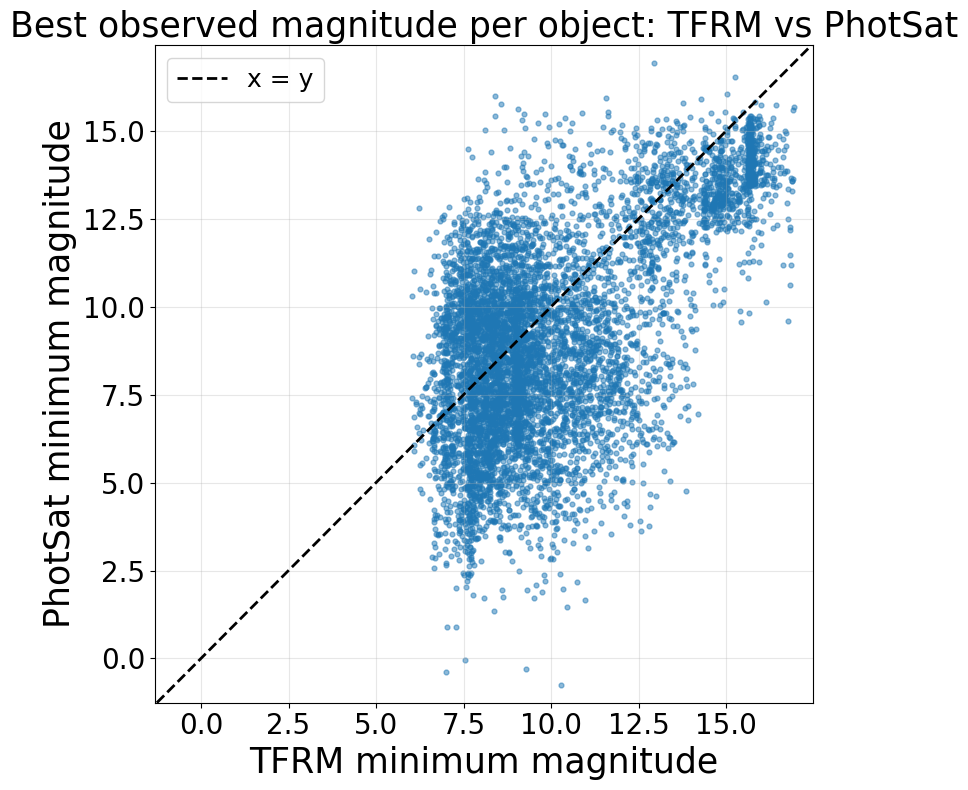

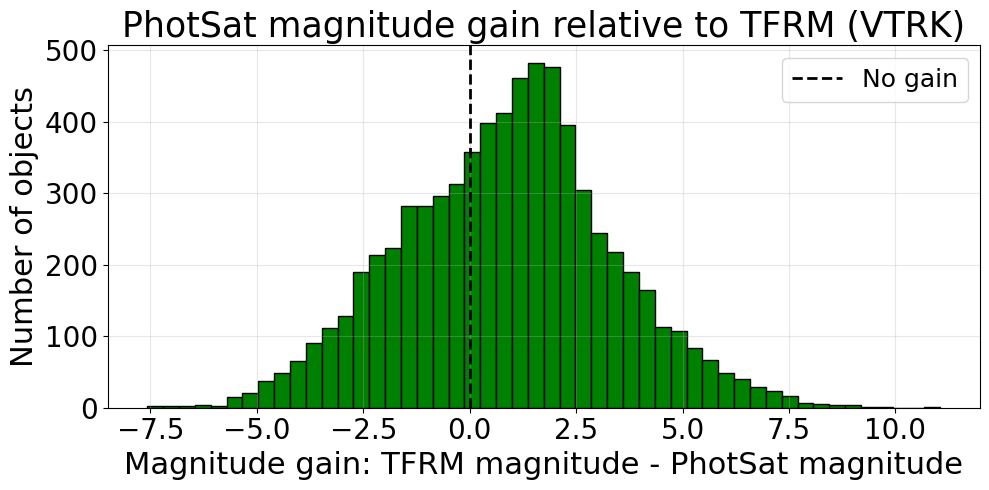

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Input files

PHOT_FILE = "detections_enriched_snr3.csv"
TFRM_FILE = "visibilities_TF21RM24VTRK.dat"


# Convert COSPAR ID to SENPLANNER short format
# Example: 1998-067A -> I98067A

def cospar_to_senplanner_short(cospar):

    if pd.isna(cospar):
        return np.nan

    s = str(cospar).strip()

    # Already in SENPLANNER format
    if s.startswith("I"):
        return s

    # Standard COSPAR format: YYYY-NNNP
    m = re.match(
        r"^(\d{4})-(\d{3})([A-Z]+)$",
        s
    )

    if m:
        year, number, piece = m.groups()
        return f"I{year[2:]}{number}{piece}"

    # Short format without I: YYNNNP
    m = re.match(
        r"^(\d{2})(\d{3})([A-Z]+)$",
        s
    )

    if m:
        year, number, piece = m.groups()
        return f"I{year}{number}{piece}"

    return np.nan


# Read PhotSat detections (SNR >= 3)

phot = pd.read_csv(PHOT_FILE)

phot["ObjectShort"] = (
    phot["COSPAR_ID"]
    .apply(cospar_to_senplanner_short)
)

phot["TrueMagnitude"] = pd.to_numeric(
    phot["TrueMagnitude"],
    errors="coerce"
)


# Obtain magnitude statistics for each unique PhotSat object
phot_best = (
    phot
    .dropna(
        subset=[
            "ObjectShort",
            "TrueMagnitude"
        ]
    )
    .groupby(
        "ObjectShort",
        as_index=False
    )
    .agg(
        PhotSat_mag_min=(
            "TrueMagnitude",
            "min"
        ),
        PhotSat_mag_median=(
            "TrueMagnitude",
            "median"
        ),
        PhotSat_mag_max=(
            "TrueMagnitude",
            "max"
        ),
        PhotSat_n_det=(
            "TrueMagnitude",
            "count"
        ),
        ObjectID=(
            "ObjectID",
            "first"
        ),
        NORAD_ID=(
            "NORAD_ID",
            "first"
        ),
        ObjectName=(
            "ObjectName",
            "first"
        ),
        COSPAR_ID=(
            "COSPAR_ID",
            "first"
        ),
        OrbitClass=(
            "OrbitClass",
            "first"
        ),
    )
)


# Read TFRM VTRK visibility file

tfrm_cols = [
    "StartTime",
    "StopTime",
    "SensorID",
    "SiteID",
    "ObjectShort",
    "Group",
    "Magnitude",
    "MagTime",
    "Dummy",
]

tfrm = pd.read_csv(
    TFRM_FILE,
    sep=r"\s+",
    skiprows=4,
    names=tfrm_cols,
    engine="python",
)

tfrm["Magnitude"] = pd.to_numeric(
    tfrm["Magnitude"],
    errors="coerce"
)


# Obtain magnitude statistics for each unique TFRM object
tfrm_best = (
    tfrm
    .dropna(
        subset=[
            "ObjectShort",
            "Magnitude"
        ]
    )
    .groupby(
        "ObjectShort",
        as_index=False
    )
    .agg(
        TFRM_mag_min=(
            "Magnitude",
            "min"
        ),
        TFRM_mag_median=(
            "Magnitude",
            "median"
        ),
        TFRM_mag_max=(
            "Magnitude",
            "max"
        ),
        TFRM_n_vis=(
            "Magnitude",
            "count"
        ),
    )
)


# Match common objects

df_comp = phot_best.merge(
    tfrm_best,
    on="ObjectShort",
    how="inner",
)

df_comp = df_comp.dropna(
    subset=[
        "PhotSat_mag_min",
        "TFRM_mag_min"
    ]
)


# Calculate PhotSat magnitude gain
# Positive value -> PhotSat observes the object brighter
# Negative value -> TFRM observes the object brighter

df_comp["Magnitude_gain_PhotSat"] = (
    df_comp["TFRM_mag_min"]
    - df_comp["PhotSat_mag_min"]
)

gain = df_comp[
    "Magnitude_gain_PhotSat"
]

n = len(df_comp)

phot_better = (
    gain > 0
).sum()

tfrm_better = (
    gain < 0
).sum()

equal = (
    gain == 0
).sum()


# Print statistics

print(
    f"Objects detected by PhotSat: "
    f"{phot_best['ObjectShort'].nunique()}"
)

print(
    f"Objects visible by TFRM:     "
    f"{tfrm_best['ObjectShort'].nunique()}"
)

print(
    f"Common objects:              "
    f"{n}"
)

print()

print(
    f"PhotSat brighter: "
    f"{phot_better} "
    f"({100 * phot_better / n:.1f}%)"
)

print(
    f"TFRM brighter:    "
    f"{tfrm_better} "
    f"({100 * tfrm_better / n:.1f}%)"
)

print(
    f"Equal:            "
    f"{equal} "
    f"({100 * equal / n:.1f}%)"
)

print(
    "\nMagnitude gain = "
    "TFRM minimum magnitude - "
    "PhotSat minimum magnitude"
)

print(
    gain.describe()
)


# Save comparison catalogue

df_comp.to_csv(
    "photsat_vs_tfrm_VTRK_magnitude_gain.csv",
    index=False
)


# Scatter plot

x = df_comp[
    "TFRM_mag_min"
]

y = df_comp[
    "PhotSat_mag_min"
]

plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    x,
    y,
    s=12,
    alpha=0.5,
)

lim_min = min(
    x.min(),
    y.min()
)

lim_max = max(
    x.max(),
    y.max()
)

margin = 0.5

lims = [
    lim_min - margin,
    lim_max + margin
]


# x = y reference line
plt.plot(
    lims,
    lims,
    "k--",
    linewidth=2,
    label="x = y",
)


plt.xlabel(
    "TFRM minimum magnitude",
    fontsize=25,
)

plt.ylabel(
    "PhotSat minimum magnitude",
    fontsize=25,
)

plt.title(
    "Best observed magnitude per object: TFRM vs PhotSat",
    fontsize=25,
)


plt.xticks(
    fontsize=20
)

plt.yticks(
    fontsize=20
)


plt.legend(
    fontsize=18
)

plt.grid(
    alpha=0.3
)


plt.axis(
    "equal"
)

plt.xlim(
    lims
)

plt.ylim(
    lims
)


plt.tight_layout()


plt.savefig(
    "PhotSat_vs_TFRM_VTRK_magnitude_scatter.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()


# Histogram of magnitude gain

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    gain,
    bins=50,
    color="green",
    edgecolor="black",
)


# Zero gain reference line
plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="No gain",
)


plt.xlabel(
    "Magnitude gain: TFRM magnitude - PhotSat magnitude",
    fontsize=22,
)

plt.ylabel(
    "Number of objects",
    fontsize=22,
)

plt.title(
    "PhotSat magnitude gain relative to TFRM (VTRK)",
    fontsize=25,
)


plt.xticks(
    fontsize=20
)

plt.yticks(
    fontsize=20
)


plt.legend(
    fontsize=18
)

plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "PhotSat_magnitude_gain_TFRM_VTRK.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


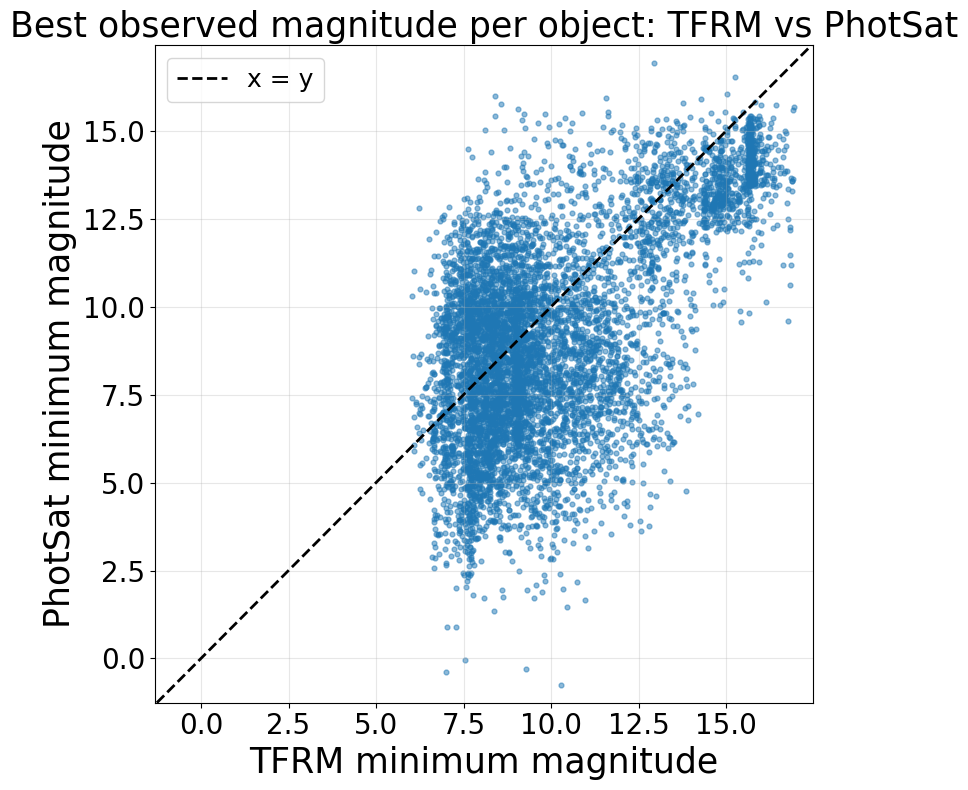

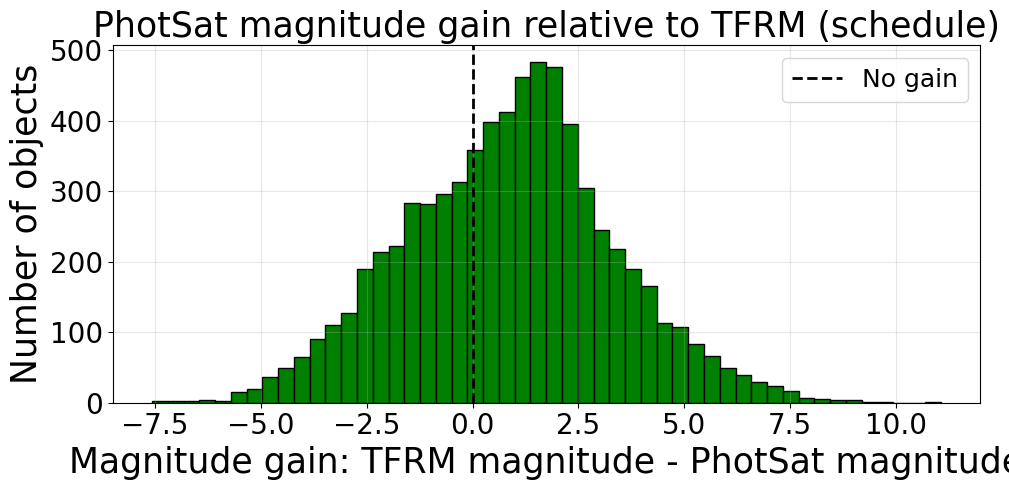

In [3]:
# Scatter
x = df_comp["TFRM_mag_min"]
y = df_comp["PhotSat_mag_min"]

plt.figure(figsize=(8, 8))
plt.scatter(
    x,
    y,
    s=12,
    alpha=0.5,
)

lim_min = min(x.min(), y.min())
lim_max = max(x.max(), y.max())
lims = [lim_min - 0.5, lim_max + 0.5]

plt.plot(
    lims,
    lims,
    "k--",
    linewidth=2,
    label="x = y",
)

plt.xlabel(
    "TFRM minimum magnitude",
    fontsize=25,
)
plt.ylabel(
    "PhotSat minimum magnitude",
    fontsize=25,
)
plt.title(
    "Best observed magnitude per object: TFRM vs PhotSat",
    fontsize=25,
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(alpha=0.3)

plt.axis("equal")
plt.xlim(lims)
plt.ylim(lims)

plt.tight_layout()

plt.savefig(
    "PhotSat_vs_TFRM_Schedule_magnitude_scatter.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Histogram magnitude gain

plt.figure(figsize=(10, 5))

plt.hist(
    gain,
    bins=50,
    color="green",
    edgecolor="black",
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="No gain",
)

plt.xlabel(
    "Magnitude gain: TFRM magnitude - PhotSat magnitude",
    fontsize=25,
)
plt.ylabel(
    "Number of objects",
    fontsize=25,
)
plt.title(
    "PhotSat magnitude gain relative to TFRM (schedule)",
    fontsize=25,
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "PhotSat_magnitude_gain_TFRM_Schedule.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [4]:
orbit_order = ["LEO", "MEO", "GEO", "GTO", "HEO", "Others"]

orbit_counts = (
    df_comp["OrbitClass"]
    .value_counts()
    .reindex(orbit_order, fill_value=0)
)

orbit_percentages = (
    100 * orbit_counts / orbit_counts.sum()
)

orbit_comparison = pd.DataFrame({
    "Objects": orbit_counts,
    "Percentage": orbit_percentages
})

print(orbit_comparison)

            Objects  Percentage
OrbitClass                     
LEO            5249   75.082249
MEO             391    5.592905
GEO             318    4.548705
GTO             251    3.590330
HEO             222    3.175511
Others          560    8.010299


In [9]:
orbit_order = ["LEO", "MEO", "GEO", "GTO", "HEO", "Others"]

# VTRK common objects

orbit_counts_vtrk = (
    df_comp["OrbitClass"]
    .value_counts()
    .reindex(orbit_order, fill_value=0)
)

orbit_percentages_vtrk = (
    100 * orbit_counts_vtrk / orbit_counts_vtrk.sum()
)

orbit_comparison_vtrk = pd.DataFrame({
    "Objects": orbit_counts_vtrk,
    "Percentage": orbit_percentages_vtrk.round(2)
})

print("VTRK ")
print(orbit_comparison_vtrk)

=== VTRK ===
            Objects  Percentage
OrbitClass                     
LEO            5249       75.08
MEO             391        5.59
GEO             318        4.55
GTO             251        3.59
HEO             222        3.18
Others          560        8.01


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SCHEDULE COMPARISON: PhotSat vs TFRM

PHOTSAT_SCHEDULE_FILE = "detections_enriched_snr3.csv"
TFRM_SCHEDULE_FILE = "detections_enriched_snr3_TFRM.csv"

phot_schedule = pd.read_csv(PHOTSAT_SCHEDULE_FILE)
tfrm_schedule = pd.read_csv(TFRM_SCHEDULE_FILE)

print("PhotSat detections:", len(phot_schedule))
print("TFRM detections:", len(tfrm_schedule))

print("PhotSat unique objects:", phot_schedule["NORAD_ID"].nunique())
print("TFRM unique objects:", tfrm_schedule["NORAD_ID"].nunique())

PhotSat detections: 37476
TFRM detections: 7400
PhotSat unique objects: 12053
TFRM unique objects: 1320


In [12]:
# Minimum magnitude per object

phot_schedule_best = (
    phot_schedule
    .dropna(subset=["NORAD_ID", "TrueMagnitude"])
    .groupby("NORAD_ID", as_index=False)
    .agg(
        PhotSat_mag=("TrueMagnitude", "min"),
        OrbitClass=("OrbitClass", "first")
    )
)

tfrm_schedule_best = (
    tfrm_schedule
    .dropna(subset=["NORAD_ID", "TrueMagnitude"])
    .groupby("NORAD_ID", as_index=False)
    .agg(
        TFRM_mag=("TrueMagnitude", "min")
    )
)

# Keep only common objects
df_comp_schedule = phot_schedule_best.merge(
    tfrm_schedule_best,
    on="NORAD_ID",
    how="inner"
)

# Magnitude difference
df_comp_schedule["Delta_mag"] = (
    df_comp_schedule["TFRM_mag"]
    - df_comp_schedule["PhotSat_mag"]
)

print("Common objects:", len(df_comp_schedule))
print(
    "Mean Δmag:",
    df_comp_schedule["Delta_mag"].mean()
)
print(
    "Median Δmag:",
    df_comp_schedule["Delta_mag"].median()
)

Common objects: 867
Mean Δmag: -0.006400574400461358
Median Δmag: -0.08418119699999949


In [13]:
orbit_order = [
    "LEO",
    "MEO",
    "GEO",
    "GTO",
    "HEO",
    "Others"
]

orbit_counts_schedule = (
    df_comp_schedule["OrbitClass"]
    .value_counts()
    .reindex(orbit_order, fill_value=0)
)

orbit_percentages_schedule = (
    100
    * orbit_counts_schedule
    / orbit_counts_schedule.sum()
)

orbit_comparison_schedule = pd.DataFrame({
    "Objects": orbit_counts_schedule,
    "Percentage": orbit_percentages_schedule.round(2)
})

print("\n SCHEDULE COMMON OBJECTS")
print(orbit_comparison_schedule)


=== SCHEDULE COMMON OBJECTS ===
            Objects  Percentage
OrbitClass                     
LEO             111       12.80
MEO              96       11.07
GEO             270       31.14
GTO             137       15.80
HEO             103       11.88
Others          150       17.30


In [14]:
orbit_order = [
    "LEO",
    "MEO",
    "GEO",
    "GTO",
    "HEO",
    "Others"
]

orbit_counts_schedule = (
    df_comp_schedule["OrbitClass"]
    .value_counts()
    .reindex(orbit_order, fill_value=0)
)

orbit_percentages_schedule = (
    100
    * orbit_counts_schedule
    / orbit_counts_schedule.sum()
)

orbit_comparison_schedule = pd.DataFrame({
    "Objects": orbit_counts_schedule,
    "Percentage": orbit_percentages_schedule.round(2)
})

print("\n SCHEDULE COMMON OBJECTS ")
print(orbit_comparison_schedule)


=== SCHEDULE COMMON OBJECTS ===
            Objects  Percentage
OrbitClass                     
LEO             111       12.80
MEO              96       11.07
GEO             270       31.14
GTO             137       15.80
HEO             103       11.88
Others          150       17.30
